In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path


In [2]:
warnings.filterwarnings("ignore")


## Load Dataset

We use `pathlib` to construct the dataset path dynamically instead of hardcoding the full file path.

This makes the notebook more portable across different environments and machines.

In [3]:
BASE_DIR=Path.cwd().parent
DATA_PATH=BASE_DIR / "data" / "raw" / "Telco-Customer-Churn.csv"

df=pd.read_csv(DATA_PATH)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.shape

(7043, 21)

Data Manipulation¶

In [8]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
num_col=df.select_dtypes(include="number").columns
cat_col=df.select_dtypes(include='object').columns

In [13]:
print(f"Numerical Columns: {', '.join(num_col)}")

Numerical Columns: SeniorCitizen, tenure, MonthlyCharges, TotalCharges, Churn


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.000,1.0000,1.00


In [15]:
df[df["tenure"] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [17]:
df = df.drop(df[df["tenure"] == 0].index)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop("customerID", axis=1)

Exploratory Data Analysis

In [20]:
demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

account_features = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [21]:
churn_stats = df["Churn"].value_counts()

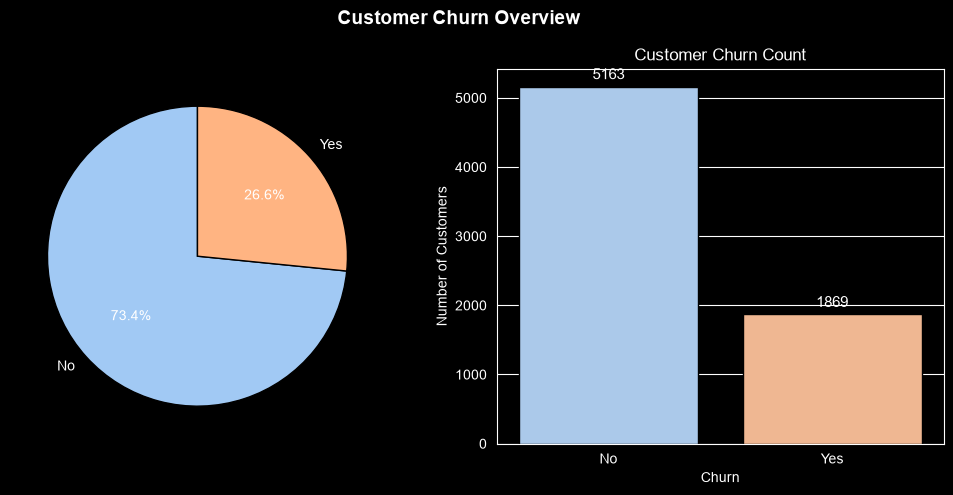

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
colors = sns.color_palette("pastel", df["Churn"].nunique())

ax[0].pie(
    churn_stats,
    labels=["No", "Yes"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[1]
)

for container in ax[1].containers:
    ax[1].bar_label(container, fontsize=11, padding=3)


ax[1].set_title("Customer Churn Count")
ax[1].set_xlabel("Churn")
ax[1].set_ylabel("Number of Customers")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["No", "Yes"])

fig.suptitle("Customer Churn Overview", fontsize=14, fontweight="bold")

plt.tight_layout();

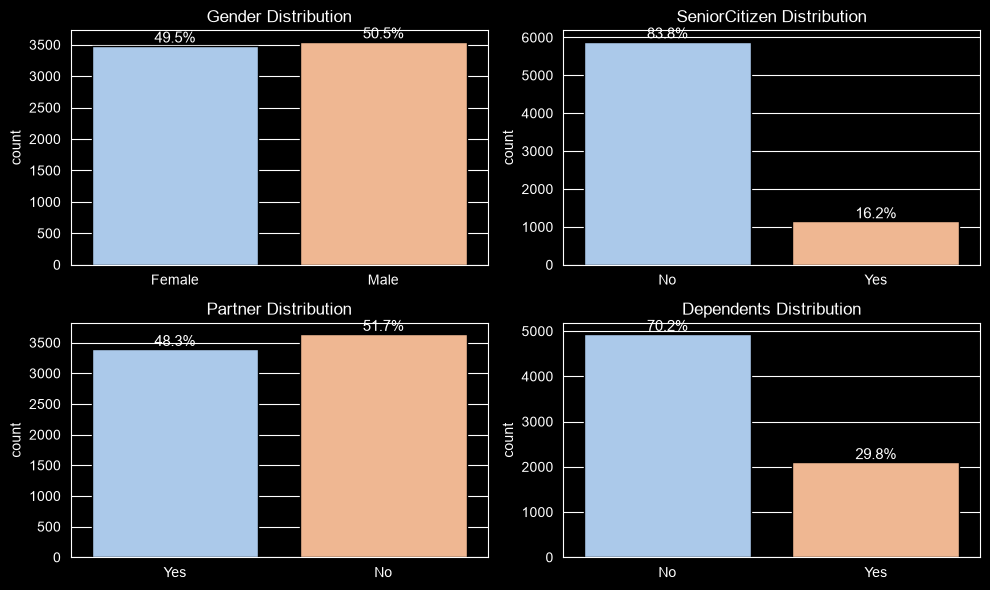

In [23]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 6)
)

axes = axes.flatten()

for ax, feature in zip(axes, demographic_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%"
                for x in container.datavalues],
            fontsize=11
        )

    ax.set_title(f"{feature.capitalize()} Distribution")
    ax.set_xlabel('')

    if feature == "SeniorCitizen":
        ax.set_title(f"{feature} Distribution")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No", "Yes"])

plt.tight_layout();


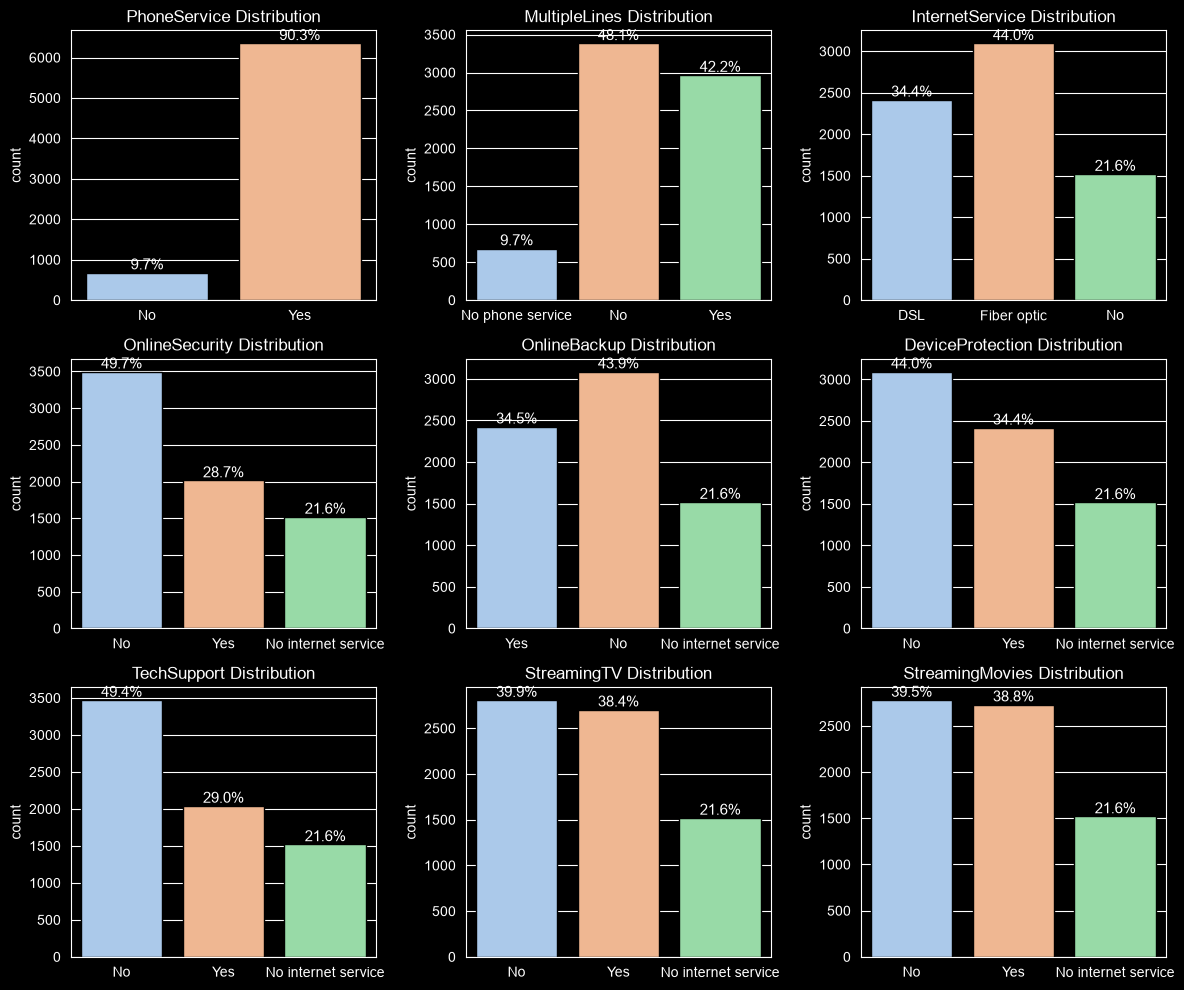

In [24]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 10)
)


axes = axes.flatten()


for ax, feature in zip(axes, service_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False,
        ax=ax
    )


    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%"
                for x in container.datavalues
            ],
            fontsize=11
        )


    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel('')


plt.tight_layout();

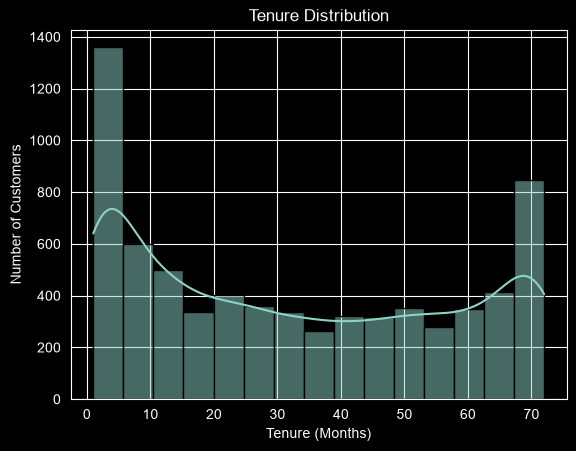

In [25]:
sns.histplot(
    data=df,
    x="tenure",
    kde=True,
    edgecolor="black"
);


plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers");

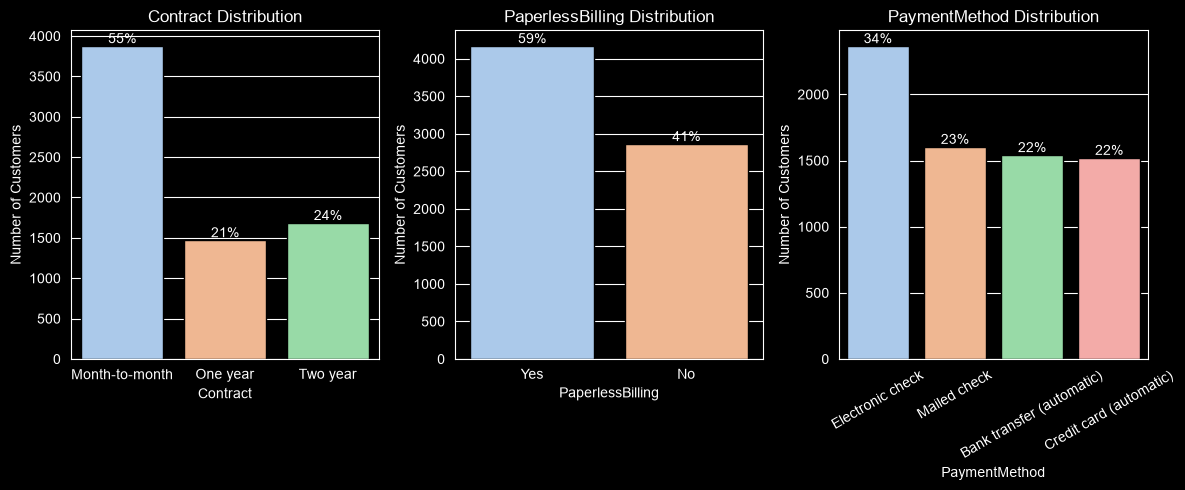

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

for ax, feature in zip(axes, account_features[1:]):
    ax = sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="pastel",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.0f}%"
                for x in container.datavalues
            ]
        )

    if feature == "PaymentMethod":
        ax.tick_params(axis="x", rotation=30)

    # Customize plot titles and axis labels

    ax.set_title(f"{feature} Distribution")
    ax.set_ylabel("Number of Customers")

# Adjust spacing between subplots

plt.tight_layout();


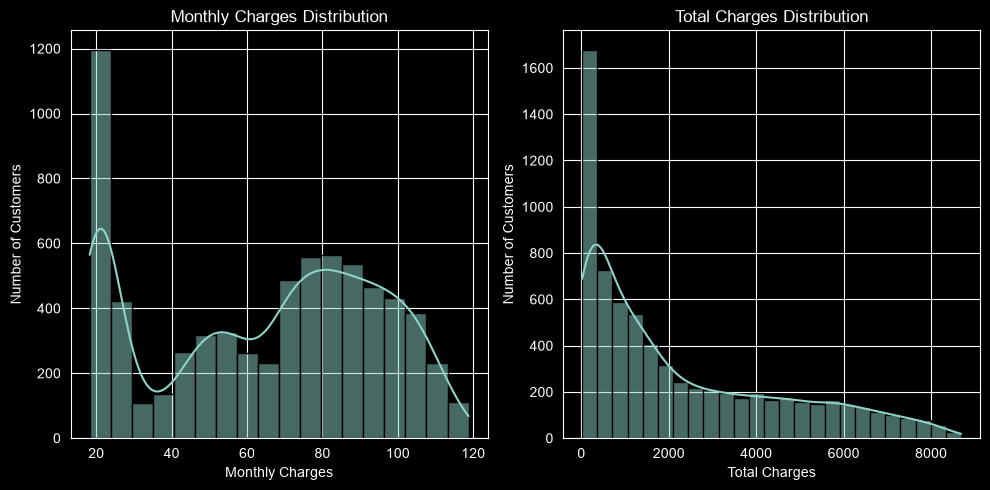

In [27]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5)
)


sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True,
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[0]
)


sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True,
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[1]
)


ax[0].set_title("Monthly Charges Distribution")
ax[0].set_xlabel("Monthly Charges")
ax[0].set_ylabel("Number of Customers")


ax[1].set_title("Total Charges Distribution")
ax[1].set_xlabel("Total Charges")
ax[1].set_ylabel("Number of Customers")


plt.tight_layout();

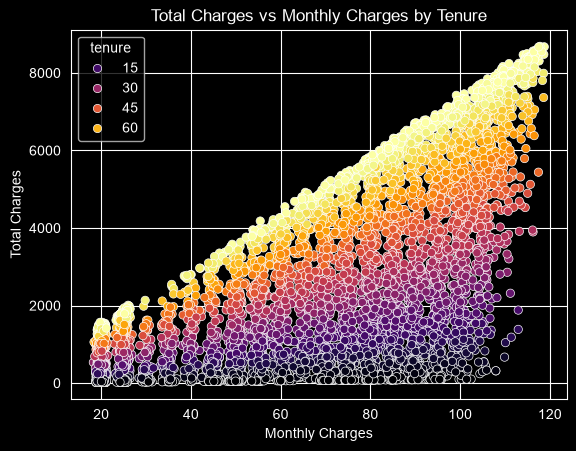

In [28]:
sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="tenure",
    palette="inferno"
)


plt.title("Total Charges vs Monthly Charges by Tenure")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges");


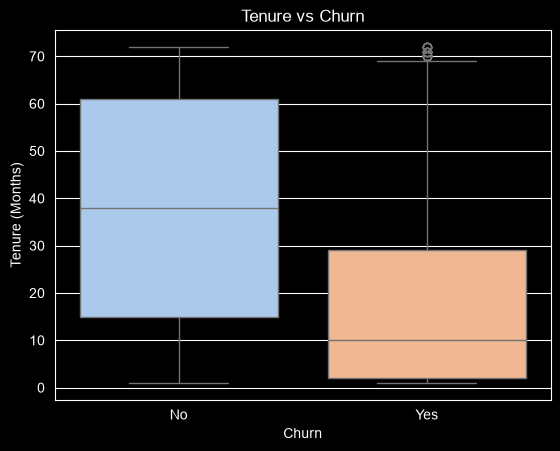

In [29]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="pastel",
    legend=False
);


plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")


plt.xticks(ticks=[0, 1], labels=["No", "Yes"]);


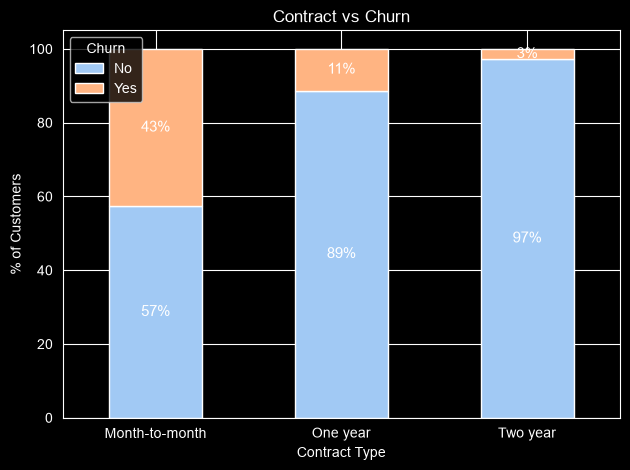

In [30]:

cross = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100


ax = cross.plot(
    kind="bar",
    stacked=True,
    color=sns.color_palette("pastel", 2)
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{x:.0f}%"
            for x in container.datavalues
        ],
        label_type="center",
        fontsize=11
    )


ax.set_title("Contract vs Churn")
ax.set_xlabel("Contract Type")
ax.set_ylabel("% of Customers")
ax.legend(title="Churn",labels=["No", "Yes"])


plt.xticks(rotation=0)
plt.tight_layout();

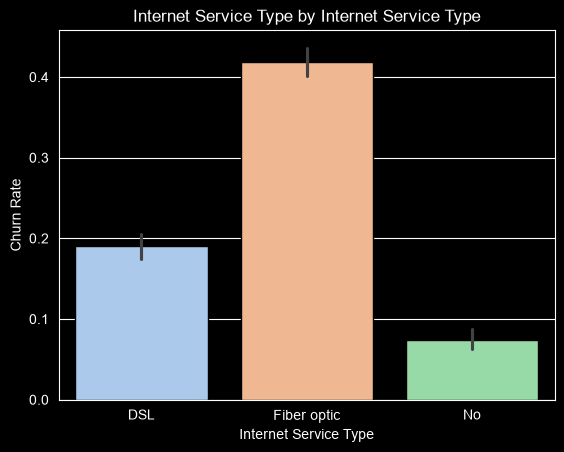

In [31]:
sns.barplot(
    data=df,
    x="InternetService",
    y="Churn",
    hue="InternetService",
    palette="pastel",
    edgecolor="black",
    legend=False
)


plt.title("Internet Service Type by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate");

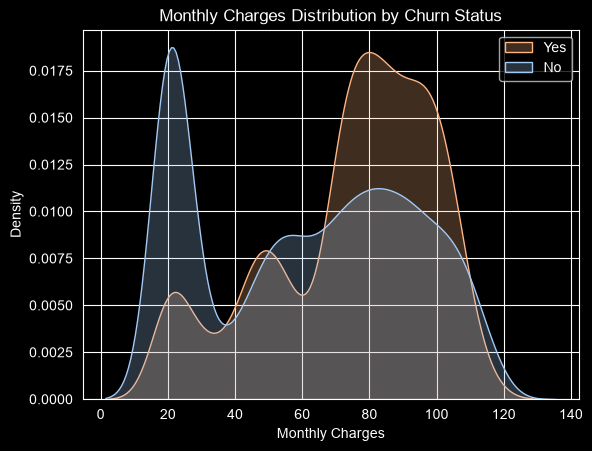

In [32]:
sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    palette="pastel",
    common_norm=False,
    fill=True,
)


plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

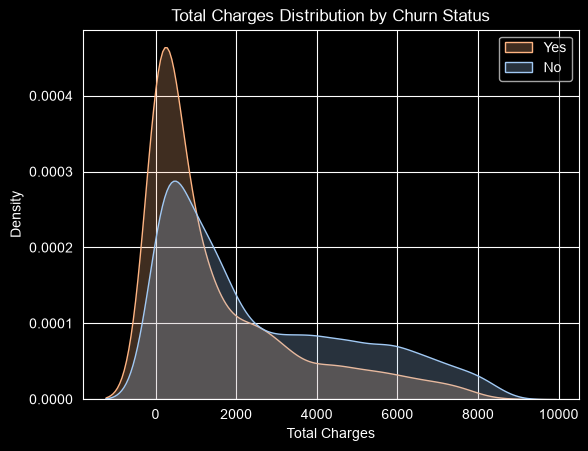

In [33]:
sns.kdeplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    palette="pastel",
    common_norm=False,
    fill=True,
);


plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

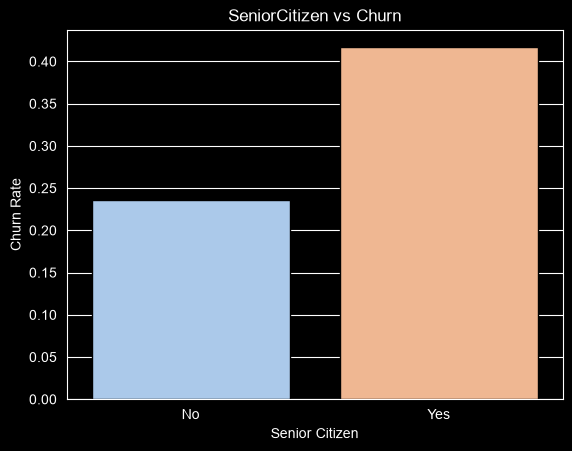

In [34]:
sns.barplot(
    data=df,
    x="SeniorCitizen",
    y="Churn",
    hue="SeniorCitizen",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ci=False
);


plt.title("SeniorCitizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"]);

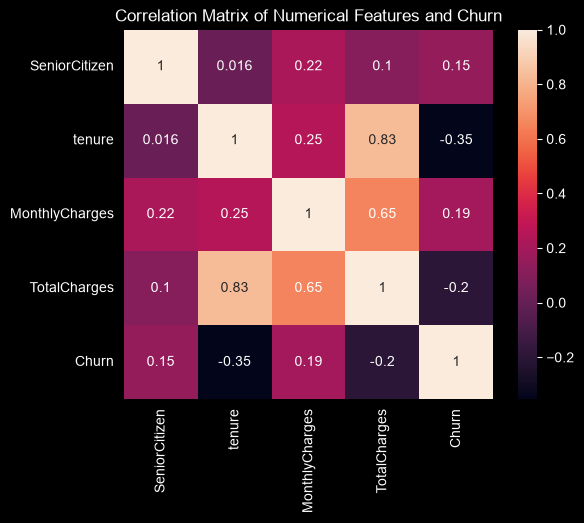

In [35]:
corr_matrix = df.corr(numeric_only=True)



sns.heatmap(
    corr_matrix,
    square=True,
    annot=True
)


plt.title("Correlation Matrix of Numerical Features and Churn");